# Percobaan 1 — Fokus perbaikan Kontras
**Preprocessing:** Grayscale + Resize + Normalisasi + Histogram Equalization

**Fitur:** GLCM (contrast, dissimilarity, homogeneity, ASM, energy, correlation, entropy)

**Klasifikasi:** KNN, SVM, Random Forest

In [16]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import os

1. Import Library
Pada cell ini, seluruh library yang dibutuhkan dalam project klasifikasi diimport sekaligus. Library cv2 digunakan untuk membaca gambar dan melakukan konversi warna atau resize. matplotlib dan seaborn digunakan untuk menampilkan visualisasi gambar maupun grafik. numpy dan pandas digunakan untuk manipulasi data matriks dan tabel. Untuk ekstraksi fitur tekstur, digunakan graycomatrix dan graycoprops dari skimage, serta entropy dari scipy. Tiga algoritma klasifikasi diimport dari sklearn, yaitu Random Forest, SVM, dan KNN, beserta fungsi pendukung untuk membagi data dan metrik evaluasi.

In [17]:
def normalize(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image)
    normalized = (image - min_val) / (max_val - min_val) * 255
    return normalized.astype(np.uint8)

2. Fungsi Normalisasi
Cell ini mendefinisikan fungsi untuk melakukan normalisasi nilai piksel citra secara manual menggunakan rumus Min-Max Scaling ke rentang 0-255. Jika citra memiliki nilai max dan min yang sama (citra polos/kosong), fungsi mengembalikan array nol untuk mencegah pembagian dengan nol. Normalisasi ini diperlukan untuk mempermudah perhitungan histogram equalization selanjutnya.

In [18]:
def histogram_equalization(image):
    hist = np.zeros(256, dtype=int)
    height, width = image.shape
    for i in range(height):
        for j in range(width):
            val = image[i, j]
            hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(hist[0:i+1])

    hasil_cdf = np.round(((cdf * 255) / (height * width)))
    
    equalized_img = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            equalized_img[i, j] = hasil_cdf[image[i, j]]
            
    return equalized_img.astype(np.uint8)

3. Fungsi Histogram Equalization
Cell ini mendefinisikan fungsi untuk melakukan *histogram equalization* secara manual untuk pemerataan distribusi kecerahan piksel. Fungsi akan menghitung histogram nilai piksel, membangun tabel Cumulative Distribution Function (CDF), dan memetakannya kembali ke nilai rentang 0-255. Langkah ini sangat penting untuk memperbaiki kontras citra agar fitur permukaannya lebih mudah diekstrak.

In [19]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

4. Fungsi Ekstraksi Fitur GLCM
Cell ini mendefinisikan serangkaian fungsi untuk mengekstrak fitur dari gambar menggunakan metode Gray Level Co-occurrence Matrix (GLCM). Terdapat fungsi utama `glcm` yang bertugas membentuk matriks berdasarkan sudut (0, 45, 90, 135 derajat) dan 7 fungsi lain untuk mengambil masing-masing nilai fitur (Correlation, Dissimilarity, Homogeneity, Contrast, ASM, Energy, Entropy). Fitur tekstur ini akan digunakan sebagai dasar klasifikasi kondisi tomat.

In [20]:
dataset_path = "Dataset"
labels = ["Matang", "Rusak", "Tua"]

data = []
contoh_gambar = {}

for label in labels:
    folder = os.path.join(dataset_path, label)
    simpan_contoh = True

    for img_name in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, img_name)
        img = cv.imread(img_path)
        if img is None:
            continue

        # 1. Grayscale
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

        # 2. Resize
        resized = cv.resize(gray, (128, 128))

        # 3. Normalisasi
        Normalisasi_result = normalize(resized)

        # 4. Histogram Equalization
        equalized = histogram_equalization(Normalisasi_result)

        if simpan_contoh:
            contoh_gambar[label] = {
                'asli'   : img,
                'gray'   : resized,
                'normalized': Normalisasi_result,
                'histogram_equalized': equalized
            }
            simpan_contoh = False

        baris = {'filename': img_name, 'label': label}
        for derajat in [0, 45, 90, 135]:
            matriks = glcm(equalized, derajat)
            baris[f'Correlation{derajat}']   = correlation(matriks)
            baris[f'Contrast{derajat}']      = contrast(matriks)
            baris[f'Dissimilarity{derajat}'] = dissimilarity(matriks)
            baris[f'Homogeneity{derajat}']   = homogenity(matriks)
            baris[f'ASM{derajat}']           = ASM(matriks)
            baris[f'Energy{derajat}']        = energy(matriks)
            baris[f'Entropy{derajat}']       = entropyGlcm(matriks)
        data.append(baris)

print(f"Total gambar diproses: {len(data)}")
print(f"Normalisasi max: {Normalisasi_result.max()}, min: {Normalisasi_result.min()}")
print(f"Equalized max: {equalized.max()}, min: {equalized.min()}")

Total gambar diproses: 294
Normalisasi max: 255, min: 0
Equalized max: 255, min: 37


5. Memproses Seluruh Dataset (Preprocessing dan Ekstraksi)
Cell ini merupakan inti pengolahan data. Proses iterasi dilakukan pada folder `Dataset` untuk membaca citra dari ketiga label: 'Matang', 'Rusak', dan 'Tua'. Tahap preprocessing yang dilakukan secara berurutan adalah: Grayscale, Resize (128x128), Normalisasi, dan Histogram Equalization. Setelah itu, gambar diekstrak fiturnya dari matriks GLCM pada keempat sudut (0, 45, 90, 135 derajat) dan datanya disimpan ke dalam sebuah list.

6. Data Understanding
Cell ini melakukan inspeksi jumlah data hasil pembacaan. Tujuannya untuk memastikan data citra berhasil terbaca dan mengetahui seberapa seimbang (balance) distribusi data per kelas sebelum lanjut ke pemodelan.

Distribusi Dataset:
  Matang: 100 gambar
  Rusak: 96 gambar
  Tua: 98 gambar


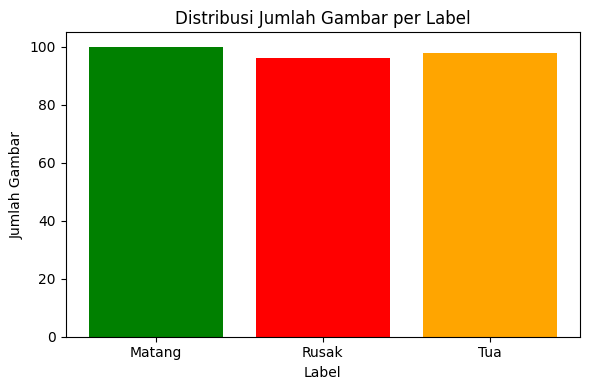

In [21]:
jumlah_per_label = {label: 0 for label in labels}
for d in data:
    jumlah_per_label[d['label']] += 1

print("Distribusi Dataset:")
for label, jumlah in jumlah_per_label.items():
    print(f"  {label}: {jumlah} gambar")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(jumlah_per_label.keys(),
       jumlah_per_label.values(),
       color=['green', 'red', 'orange'])
ax.set_title('Distribusi Jumlah Gambar per Label')
ax.set_xlabel('Label')
ax.set_ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

7. Visualisasi Gambar Asli
Menampilkan masing-masing satu sampel citra asli dari setiap kelas ('Matang', 'Rusak', 'Tua') untuk memperlihatkan kondisi citra awal.

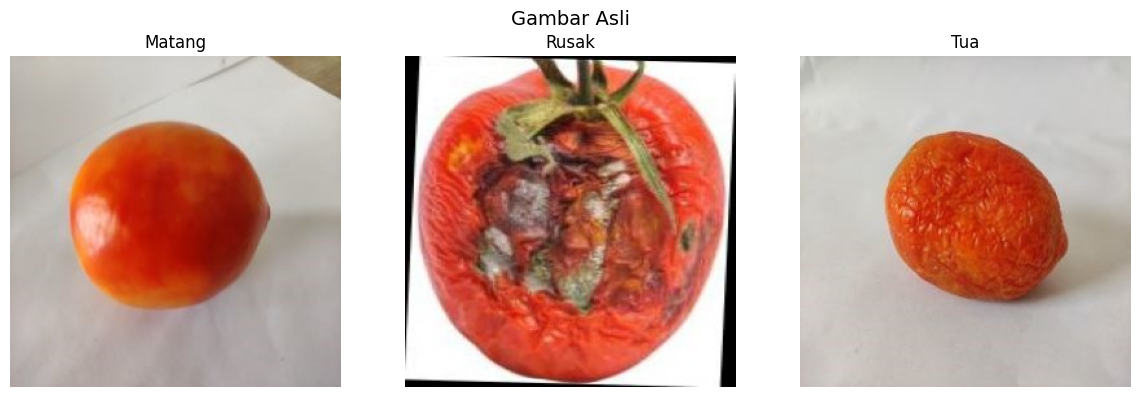

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(cv.cvtColor(contoh_gambar[label]['asli'], cv.COLOR_BGR2RGB))
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('Gambar Asli', fontsize=14)
plt.tight_layout()
plt.show()

8. Visualisasi Grayscale dan Resize
Menampilkan citra sampel setelah melalui tahap Grayscale dan Resize menjadi 128x128. Warna RGB dihilangkan agar pengolahan GLCM bisa bekerja (hanya butuh piksel intensitas tunggal).

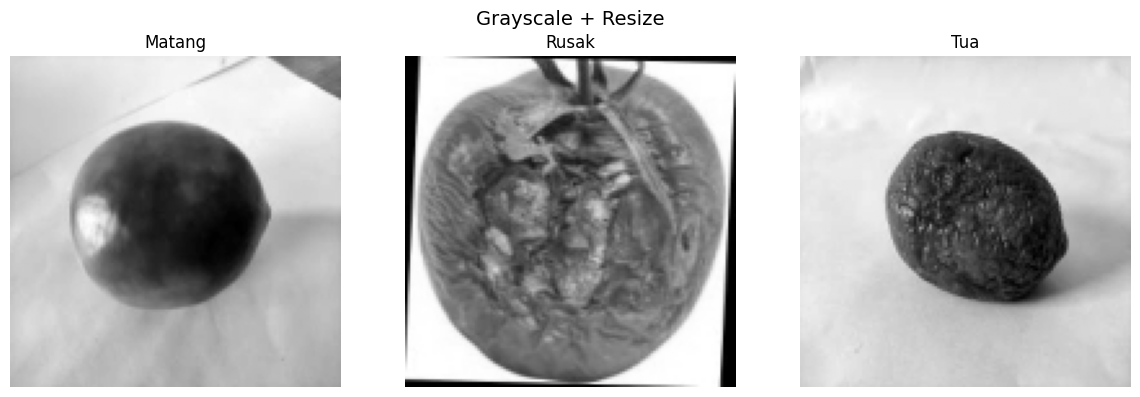

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(contoh_gambar[label]['gray'], cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('Grayscale + Resize', fontsize=14)
plt.tight_layout()
plt.show()

9. Visualisasi Hasil Normalisasi
Menampilkan citra sampel setelah nilai pikselnya dinormalisasi menggunakan Min-Max ke rentang 0-255.

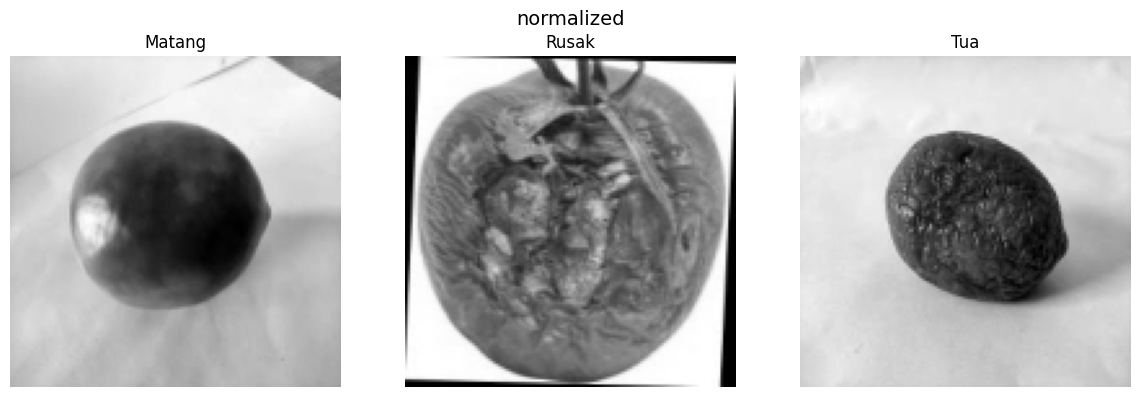

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(contoh_gambar[label]['normalized'], cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('normalized', fontsize=14)
plt.tight_layout()
plt.show()

10. Visualisasi Hasil Histogram Equalization
Menampilkan citra sampel setelah pemerataan histogram. Dapat dilihat kontras citra telah diperbaiki dan dipertegas sehingga ciri dari citra 'Matang', 'Rusak', dan 'Tua' menjadi lebih menonjol.

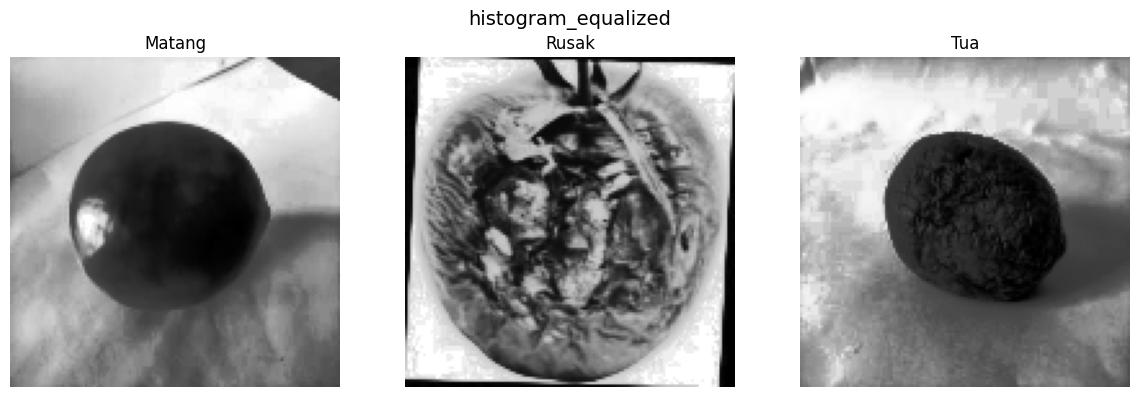

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(contoh_gambar[label]['histogram_equalized'], cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('histogram_equalized', fontsize=14)
plt.tight_layout()
plt.show()

11. Penyimpanan Fitur dan Seleksi Berdasarkan Korelasi
Cell ini menyimpan hasil ekstraksi 28 fitur tekstur GLCM menjadi satu file csv (hasil_p1.csv) dan menampilkan heatmap matriks korelasinya. Kemudian dilakukan reduksi fitur untuk membuang fitur-fitur yang terindikasi sangat berkorelasi kuat (korelasi > 0.95), guna menghindari masalah multikolinearitas dalam pembelajaran model.

Total gambar: 294
           filename   label  Correlation0   Contrast0  Dissimilarity0  \
0    Matang (1).jpg  Matang      0.987846  134.127276        4.689407   
1   Matang (10).jpg  Matang      0.985718  157.226255        7.206816   
2  Matang (100).jpg  Matang      0.979497  218.735605        8.478593   
3   Matang (11).jpg  Matang      0.984948  165.910249        7.236897   
4   Matang (12).jpg  Matang      0.986702  146.575726        6.763472   

   Homogeneity0      ASM0   Energy0  Entropy0  Correlation45  ...     ASM90  \
0      0.405593  0.002684  0.051806  6.638871       0.980368  ...  0.002917   
1      0.296626  0.001996  0.044671  6.617009       0.976521  ...  0.002530   
2      0.287392  0.001494  0.038658  7.056670       0.957729  ...  0.001751   
3      0.312333  0.002326  0.048232  6.570116       0.973936  ...  0.002303   
4      0.302998  0.002020  0.044944  6.732622       0.978426  ...  0.001816   

   Energy90  Entropy90  Correlation135  Contrast135  Dissimilarity13

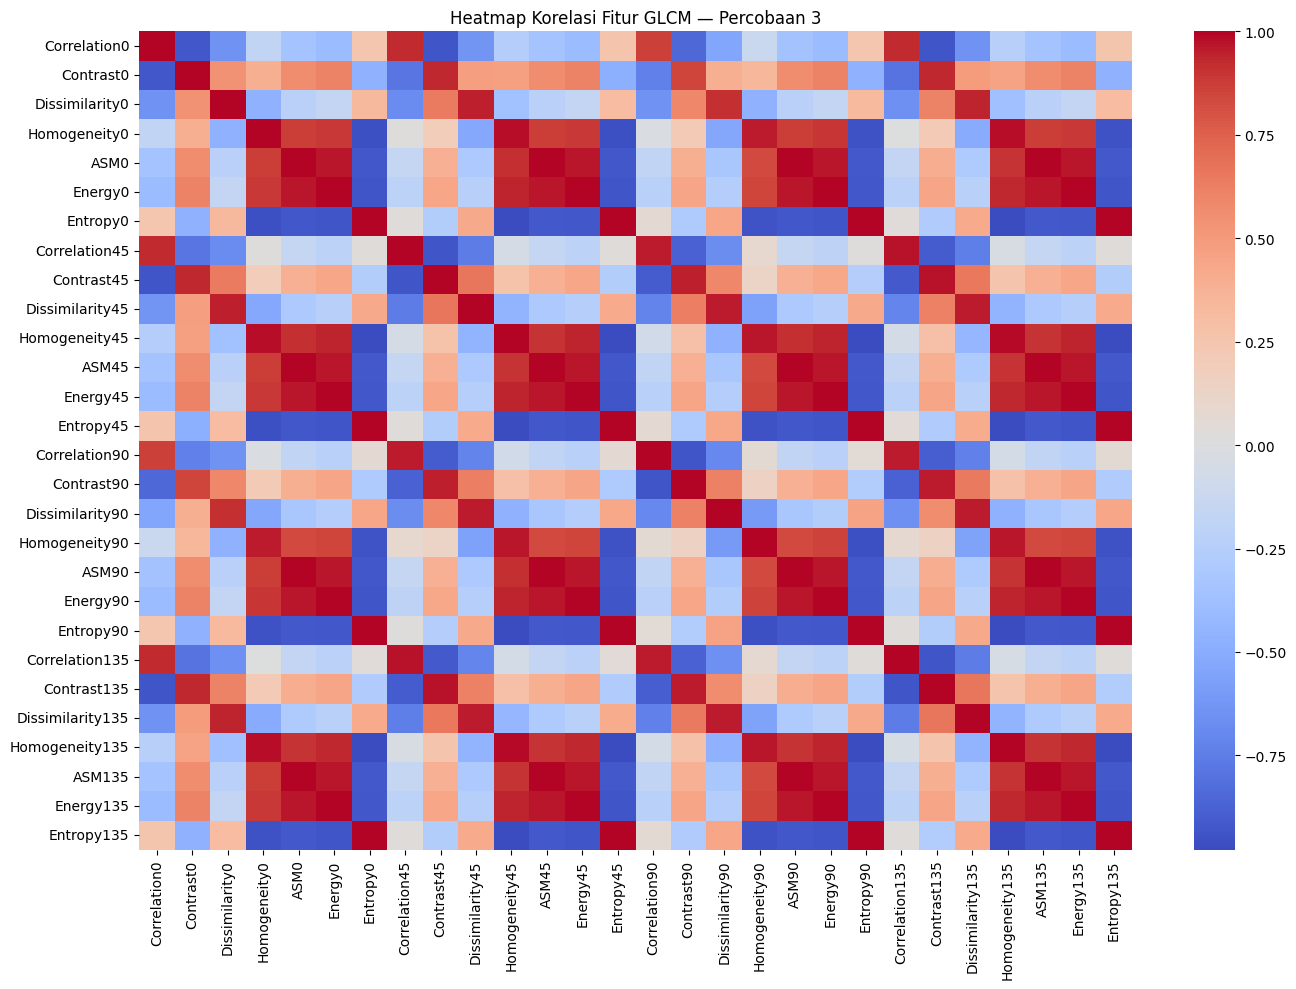

In [26]:
df = pd.DataFrame(data)
df.to_csv("hasil_p1.csv", index=False)
print(f"Total gambar: {len(df)}")
print(df.head())

# Feature Selection — hapus fitur korelasi tinggi > 0.95
fitur = df.drop(columns=['filename', 'label'])
corr_matrix = fitur.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
drop_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"\nFitur dihapus (korelasi tinggi): {drop_cols}")
fitur_selected = fitur.drop(columns=drop_cols)
print(f"Fitur tersisa: {fitur_selected.shape[1]} kolom")

# Heatmap Korelasi
plt.figure(figsize=(14, 10))
sns.heatmap(fitur.corr(), cmap='coolwarm', annot=False)
plt.title('Heatmap Korelasi Fitur GLCM — Percobaan 3')
plt.tight_layout()
plt.show()

In [27]:
X = fitur_selected
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisasi fitur (standardisasi)
X_mean  = X_train.mean()
X_std   = X_train.std()
X_train = (X_train - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

print(f"Data latih : {X_train.shape}")
print(f"Data uji   : {X_test.shape}")

Data latih : (235, 7)
Data uji   : (59, 7)


12. Pemisahan Data dan Standarisasi
Cell ini digunakan untuk membagi dataset fitur hasil reduksi menjadi data latih (X_train) dan data uji (X_test) menggunakan proporsi 80:20. Setelah itu dilakukan standarisasi (Z-score) agar seluruh data memiliki skala (rata-rata 0 dan standar deviasi 1) yang sama, ini sangat penting terutama untuk model berbasis jarak seperti KNN dan SVM.

In [28]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Tabel Akurasi
hasil = pd.DataFrame({
    'Model'   : ['Random Forest', 'SVM', 'KNN'],
    'Akurasi' : [
        f"{accuracy_score(y_test, y_pred_rf)  * 100:.2f}%",
        f"{accuracy_score(y_test, y_pred_svm) * 100:.2f}%",
        f"{accuracy_score(y_test, y_pred_knn) * 100:.2f}%"
    ]
})
print("===== HASIL PERCOBAAN 3 =====")
print(hasil.to_string(index=False))

===== HASIL PERCOBAAN 3 =====
        Model Akurasi
Random Forest  72.88%
          SVM  64.41%
          KNN  69.49%


13. Pelatihan Tiga Algoritma
Cell ini melatih tiga model klasifikasi, yaitu Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbors (KNN). Setelah tahap `fit` (pelatihan), dilakukan prediksi `predict` terhadap data tes untuk selanjutnya dievaluasi.

In [29]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm))

print("=== KNN ===")
print(classification_report(y_test, y_pred_knn))

=== Random Forest ===
              precision    recall  f1-score   support

      Matang       0.74      0.77      0.76        22
       Rusak       0.78      0.82      0.80        17
         Tua       0.67      0.60      0.63        20

    accuracy                           0.73        59
   macro avg       0.73      0.73      0.73        59
weighted avg       0.73      0.73      0.73        59

=== SVM ===
              precision    recall  f1-score   support

      Matang       0.68      0.77      0.72        22
       Rusak       0.90      0.53      0.67        17
         Tua       0.50      0.60      0.55        20

    accuracy                           0.64        59
   macro avg       0.69      0.63      0.65        59
weighted avg       0.68      0.64      0.65        59

=== KNN ===
              precision    recall  f1-score   support

      Matang       0.70      0.86      0.78        22
       Rusak       0.70      0.82      0.76        17
         Tua       0.67      

14. Laporan Klasifikasi
Cell ini memanggil fungsi `classification_report` untuk mengevaluasi metrik Akurasi, Presisi, Recall, dan F1-Score dari hasil prediksi masing-masing model yang telah diuji.

15. Visualisasi Confusion Matrix
Cell ini menampilkan tingkat akurasi atau salah tebak masing-masing label dari setiap model dalam bentuk heatmap Confusion Matrix. Sumbu Y adalah kelas aktual, sedangkan sumbu X adalah prediksi dari model.

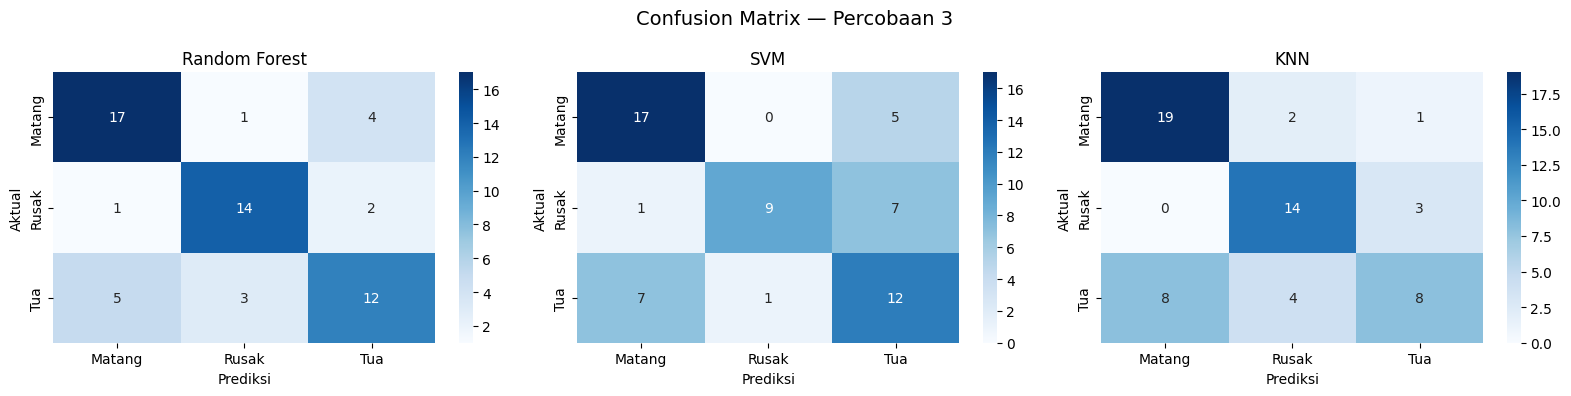

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names = ['Random Forest', 'SVM', 'KNN']
preds       = [y_pred_rf, y_pred_svm, y_pred_knn]

for i, (name, pred) in enumerate(zip(model_names, preds)):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Percobaan 3', fontsize=14)
plt.tight_layout()
plt.show()